In [1]:
import matplotlib
import matplotlib.lines as lines
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(os.path.join("/data/swein/Documents")))

In [2]:
from ggwd.utils.configreader import ConfigReader
from ggwd.utils.samplegenerator import SampleGenerator
from ggwd.utils.types import crop_time_series
from ggwd.utils.waveforms import get_detector_signals, get_waveform

/data/swein/venvs/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [3]:
config_reader = ConfigReader("waveform_params.ini")   
sample_parameters = config_reader.sample_parameters
sample_length = sample_parameters["sample_length"]
sampling_rate = sample_parameters["sampling_rate"]
delta_t = sample_parameters["delta_t"]
delta_f = sample_parameters["delta_f"]
td_length  = sample_parameters["td_length"]
fd_length = sample_parameters["fd_length"]
f_lower = sample_parameters["f_lower"]
bandpass_lower = sample_parameters["bandpass_lower"]
bandpass_upper = sample_parameters["bandpass_upper"]     
whiten_segment_duration = sample_parameters["whiten_segment_duration"]
whiten_max_filter_duration = sample_parameters["whiten_max_filter_duration"]
parameters = config_reader.draw_parameters()
noise_parameters = parameters["noise_parameters"]
waveform_parameters = parameters["waveform_parameters"]
simulation_parameters = parameters["simulation_parameters"]
antenna_parameters = parameters["antenna_parameters"]

In [4]:
np.random.seed(42)
waveform = get_waveform(td_length=td_length,
                        delta_t=delta_t,
                        sample_length=sample_length,
                        f_lower=f_lower,
                        fade_on_alpha=waveform_parameters["fade_on_alpha"][0], 
                        merger_time=waveform_parameters["merger_time"][0],
                        waveform_parameters={key: val[0] for key, val 
                                             in simulation_parameters.items()})
waveform = [crop_time_series(w, (0, sample_length)) for w in waveform]

detector_signals = get_detector_signals(waveform, 
                                        right_ascension=antenna_parameters["right_ascension"][0], 
                                        declination=antenna_parameters["declination"][0], 
                                        polarization=antenna_parameters["polarization"][0], 
                                        t_gps=antenna_parameters["t_gps"][0])

simulation_parameters["mass1"][0]=49.707021081690506
simulation_parameters["mass2"][0]=39.780814790925746
simulation_parameters["spin1z"][0]=0.726391600960692
simulation_parameters["spin2z"][0]=0.41637277812214324
simulation_parameters["inclination"][0]=158.64339170755778*np.pi/180
simulation_parameters["coa_phase"][0]=147.83272501038448*np.pi/180
antenna_parameters["right_ascension"][0]=263.1314980078695*np.pi/180
antenna_parameters["declination"][0]=64.58228938895465*np.pi/180
antenna_parameters["polarization"][0]=77.87802232255486*np.pi/180
waveform_parameters["nomf_snr"][0]=11.251966972680957

print(f"{simulation_parameters["mass1"][0]=}\n" 
      f"{simulation_parameters["mass2"][0]=}\n" 
      f"{simulation_parameters["spin1z"][0]=}\n"
      f"{simulation_parameters["spin2z"][0]=}\n"
      f"{simulation_parameters["inclination"][0]*180/np.pi=}\n"
      f"{simulation_parameters["coa_phase"][0]*180/np.pi=}")

print(f"{antenna_parameters["right_ascension"][0]*180/np.pi=}\n" 
      f"{antenna_parameters["declination"][0]*180/np.pi=}\n"
      f"{antenna_parameters["polarization"][0]*180/np.pi=}")

print(f"{waveform_parameters["nomf_snr"][0]=}")

simulation_parameters["mass1"][0]=49.707021081690506
simulation_parameters["mass2"][0]=39.780814790925746
simulation_parameters["spin1z"][0]=0.726391600960692
simulation_parameters["spin2z"][0]=0.41637277812214324
simulation_parameters["inclination"][0]*180/np.pi=158.64339170755778
simulation_parameters["coa_phase"][0]*180/np.pi=147.83272501038448
antenna_parameters["right_ascension"][0]*180/np.pi=263.1314980078695
antenna_parameters["declination"][0]*180/np.pi=64.58228938895465
antenna_parameters["polarization"][0]*180/np.pi=77.87802232255486
waveform_parameters["nomf_snr"][0]=11.251966972680957


In [5]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

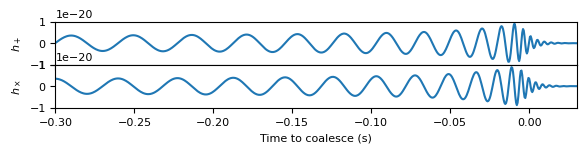

In [6]:
time = np.arange(td_length)*delta_t - waveform_parameters["merger_time"][0]*sample_length
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(15/2.54, 4/2.54), sharex=True, sharey=True)
ax1.plot(time, waveform[0], c="C0")
ax2.plot(time, waveform[1], c="C0")
low, high = ax1.get_ylim()
bound = max(abs(low), abs(high))
ax1.set_ylim(-bound, bound)
ax1.set_ylabel(r"$h_+$")
ax2.set_ylabel(r"$h_\times$")
ax2.set_xlabel("Time to coalesce (s)")
ax1.set_xlim(-0.3, 0.03)
fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig("waveform.png", dpi=300, bbox_inches="tight")

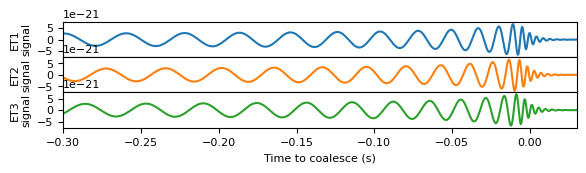

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(15/2.54, 4.5/2.54), sharex=True, sharey=True)
ax1.plot(time, detector_signals["e1"], c="C0")
ax2.plot(time, detector_signals["e2"], c="C1")
ax3.plot(time, detector_signals["e3"], c="C2")
low, high = ax1.get_ylim()
bound = max(abs(low), abs(high))
ax1.set_ylim(-bound, bound)
ax1.set_ylabel("ET1\nsignal")
ax2.set_ylabel("ET2\nsignal")
ax3.set_ylabel("ET3\nsignal")
ax3.set_xlabel("Time to coalesce (s)")
ax1.set_xlim(-0.3, 0.03)
fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig("projection.png", dpi=300, bbox_inches="tight")

[np.float64(6.3927634725075855), np.float64(9.081368027612811)]


/tmp/ipykernel_2427313/2354866650.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


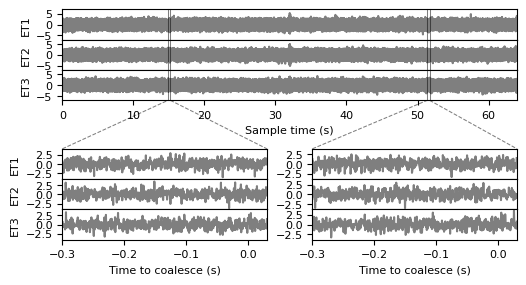

In [26]:
sample_generator = SampleGenerator("two_signals_params.ini")
seed = 1 # np.random.randint(1_000_000_000)
rng = np.random.default_rng(seed)
np.random.seed(seed)
out = sample_generator._generate_sample(rng)
print(out["parameters"]["waveform_parameters"]["nomf_snr"])

plot_height = 1
margin = 1.6
fig_width, fig_height = 15, (margin+6*plot_height)
fig = plt.figure(figsize=(fig_width/3.3,fig_height/3.3))
ax1 = fig.add_axes(rect=(0,(5*plot_height+margin)/fig_height,1,plot_height/fig_height))
ax1.axes.get_xaxis().set_visible(False)
ax2 = fig.add_axes(rect=(0,(4*plot_height+margin)/fig_height,1,plot_height/fig_height), sharex=ax1, sharey=ax1)
ax2.axes.get_xaxis().set_visible(False)
ax3 = fig.add_axes(rect=(0,(3*plot_height+margin)/fig_height,1,plot_height/fig_height), sharex=ax1, sharey=ax1)
ax4 = fig.add_axes(rect=(0,2*plot_height/fig_height,0.45,plot_height/fig_height))
ax4.axes.get_xaxis().set_visible(False)
ax5 = fig.add_axes(rect=(0,plot_height/fig_height,0.45,plot_height/fig_height), sharex=ax4, sharey=ax4)
ax5.axes.get_xaxis().set_visible(False)
ax6 = fig.add_axes(rect=(0,0,0.45,plot_height/fig_height), sharex=ax4, sharey=ax4)
ax7 = fig.add_axes(rect=(0.55,2*plot_height/fig_height,0.45,plot_height/fig_height))
ax7.axes.get_xaxis().set_visible(False)
ax8 = fig.add_axes(rect=(0.55,plot_height/fig_height,0.45,plot_height/fig_height), sharex=ax7, sharey=ax7)
ax8.axes.get_xaxis().set_visible(False)
ax9 = fig.add_axes(rect=(0.55,0,0.45,plot_height/fig_height), sharex=ax7, sharey=ax7)

merger_time0, merger_time1 = np.sort(np.array(out["parameters"]["waveform_parameters"]["merger_time"]))*sample_generator.sample_length
time = np.arange(sample_generator.td_length)*sample_generator.delta_t 
standardize = lambda x: (x-np.mean(x))/np.std(x)
ax1.plot(time, standardize(out["sample"]["e1"]), c="tab:gray")
ax2.plot(time, standardize(out["sample"]["e2"]), c="tab:gray")
ax3.plot(time, standardize(out["sample"]["e3"]), c="tab:gray")
ax1.set_ylabel("ET1")
ax2.set_ylabel("ET2")
ax3.set_ylabel("ET3")
ax3.set_xlabel("Sample time (s)")
ax1.set_xlim(0, sample_length)
low, high = ax1.get_ylim()
bound = max(abs(low), abs(high))
a = 1.2
ax1.set_ylim(-a*bound, a*bound)

mask = np.logical_and(-0.3<=time-merger_time0, time-merger_time0<0.03)
ax4.plot(time[mask]-merger_time0, standardize(out["sample"]["e1"][mask]), c="tab:gray")
ax5.plot(time[mask]-merger_time0, standardize(out["sample"]["e2"][mask]), c="tab:gray")
ax6.plot(time[mask]-merger_time0, standardize(out["sample"]["e3"][mask]), c="tab:gray")
ax4.set_ylabel("ET1")
ax5.set_ylabel("ET2")
ax6.set_ylabel("ET3")
ax6.set_xlabel("Time to coalesce (s)")
ax4.set_xlim(-0.3, 0.03)
low, high = ax4.get_ylim()
bound = max(abs(low), abs(high))
ax4.set_ylim(-bound, bound)

fig.add_artist(lines.Line2D([0, (merger_time0-0.3)/sample_length], 
                            [3*plot_height/fig_height, (3*plot_height+margin)/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time0+0.03)/sample_length, 0.45], 
                            [(3*plot_height+margin)/fig_height, 3*plot_height/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time0-0.3)/sample_length, (merger_time0-0.3)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time0+0.03)/sample_length, (merger_time0+0.03)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))

mask = np.logical_and(-0.3<=time-merger_time1, time-merger_time1<0.03)
ax7.plot(time[mask]-merger_time1, standardize(out["sample"]["e1"][mask]), c="tab:gray")
ax8.plot(time[mask]-merger_time1, standardize(out["sample"]["e2"][mask]), c="tab:gray")
ax9.plot(time[mask]-merger_time1, standardize(out["sample"]["e3"][mask]), c="tab:gray")
ax9.set_xlabel("Time to coalesce (s)")
ax7.set_xlim(-0.3, 0.03)
low, high = ax7.get_ylim()
bound = max(abs(low), abs(high))
ax7.set_ylim(-bound, bound)

fig.add_artist(lines.Line2D([0.55, (merger_time1-0.3)/sample_length], 
                            [3*plot_height/fig_height, (3*plot_height+margin)/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time1+0.03)/sample_length, 1], 
                            [(3*plot_height+margin)/fig_height, 3*plot_height/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time1-0.3)/sample_length, (merger_time1-0.3)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time1+0.03)/sample_length, (merger_time1+0.03)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))

fig.tight_layout()
fig.savefig("sample.png", dpi=300, bbox_inches="tight")

[np.float64(6.3927634725075855), np.float64(9.081368027612811)]


/tmp/ipykernel_2427313/2763785467.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


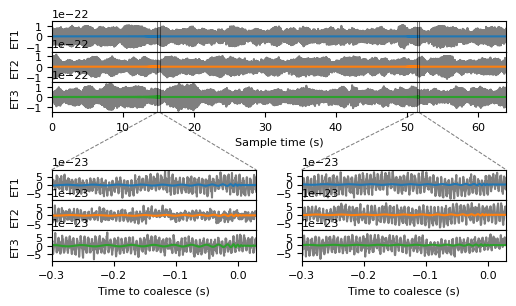

In [20]:
sample_generator = SampleGenerator("two_signals_params.ini")
rng = np.random.default_rng(seed)
sample_generator.whiten_segment_duration = None
sample_generator.whiten_max_filter_duration = None
np.random.seed(seed)
out = sample_generator._generate_sample(rng)
print(out["parameters"]["waveform_parameters"]["nomf_snr"])

plot_height = 1
margin = 1.9
fig_width, fig_height = 15, (margin+6*plot_height)
fig = plt.figure(figsize=(fig_width/3.3,fig_height/3.3))
ax1 = fig.add_axes(rect=(0,(5*plot_height+margin)/fig_height,1,plot_height/fig_height))
ax1.axes.get_xaxis().set_visible(False)
ax2 = fig.add_axes(rect=(0,(4*plot_height+margin)/fig_height,1,plot_height/fig_height), sharex=ax1, sharey=ax1)
ax2.axes.get_xaxis().set_visible(False)
ax3 = fig.add_axes(rect=(0,(3*plot_height+margin)/fig_height,1,plot_height/fig_height), sharex=ax1, sharey=ax1)
ax4 = fig.add_axes(rect=(0,2*plot_height/fig_height,0.45,plot_height/fig_height))
ax4.axes.get_xaxis().set_visible(False)
ax5 = fig.add_axes(rect=(0,plot_height/fig_height,0.45,plot_height/fig_height), sharex=ax4, sharey=ax4)
ax5.axes.get_xaxis().set_visible(False)
ax6 = fig.add_axes(rect=(0,0,0.45,plot_height/fig_height), sharex=ax4, sharey=ax4)
ax7 = fig.add_axes(rect=(0.55,2*plot_height/fig_height,0.45,plot_height/fig_height))
ax7.axes.get_xaxis().set_visible(False)
ax8 = fig.add_axes(rect=(0.55,plot_height/fig_height,0.45,plot_height/fig_height), sharex=ax7, sharey=ax7)
ax8.axes.get_xaxis().set_visible(False)
ax9 = fig.add_axes(rect=(0.55,0,0.45,plot_height/fig_height), sharex=ax7, sharey=ax7)

merger_time0, merger_time1 = np.sort(np.array(out["parameters"]["waveform_parameters"]["merger_time"]))*sample_generator.sample_length
time = np.arange(sample_generator.td_length)*sample_generator.delta_t 
ax1.plot(time, out["sample"]["e1"], c="tab:gray")
ax2.plot(time, out["sample"]["e2"], c="tab:gray")
ax3.plot(time, out["sample"]["e3"], c="tab:gray")
ax1.plot(time, out["waveform"]["e1"], c="C0")
ax2.plot(time, out["waveform"]["e2"], c="C1")
ax3.plot(time, out["waveform"]["e3"], c="C2")
# ax1.set_ylabel("ET1\nstrain")
# ax2.set_ylabel("ET2\nstrain")
# ax3.set_ylabel("ET3\nstrain")
ax1.set_ylabel("ET1")
ax2.set_ylabel("ET2")
ax3.set_ylabel("ET3")
ax3.set_xlabel("Sample time (s)")
ax1.set_xlim(0, sample_length)

mask = np.logical_and(-0.3<=time-merger_time0, time-merger_time0<0.03)
ax4.plot(time[mask]-merger_time0, out["sample"]["e1"][mask], c="tab:gray")
ax5.plot(time[mask]-merger_time0, out["sample"]["e2"][mask], c="tab:gray")
ax6.plot(time[mask]-merger_time0, out["sample"]["e3"][mask], c="tab:gray")
ax4.plot(time[mask]-merger_time0, out["waveform"]["e1"][mask], c="C0")
ax5.plot(time[mask]-merger_time0, out["waveform"]["e2"][mask], c="C1")
ax6.plot(time[mask]-merger_time0, out["waveform"]["e3"][mask], c="C2")
ax4.set_ylabel("ET1")
ax5.set_ylabel("ET2")
ax6.set_ylabel("ET3")
ax6.set_xlabel("Time to coalesce (s)")
ax4.set_xlim(-0.3, 0.03)

fig.add_artist(lines.Line2D([0, (merger_time0-0.3)/sample_length], 
                            [3*plot_height/fig_height, (3*plot_height+margin)/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time0+0.03)/sample_length, 0.45], 
                            [(3*plot_height+margin)/fig_height, 3*plot_height/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time0-0.3)/sample_length, (merger_time0-0.3)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time0+0.03)/sample_length, (merger_time0+0.03)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))

mask = np.logical_and(-0.3<=time-merger_time1, time-merger_time1<0.03)
ax7.plot(time[mask]-merger_time1, out["sample"]["e1"][mask], c="tab:gray")
ax8.plot(time[mask]-merger_time1, out["sample"]["e2"][mask], c="tab:gray")
ax9.plot(time[mask]-merger_time1, out["sample"]["e3"][mask], c="tab:gray")
ax7.plot(time[mask]-merger_time1, out["waveform"]["e1"][mask], c="C0")
ax8.plot(time[mask]-merger_time1, out["waveform"]["e2"][mask], c="C1")
ax9.plot(time[mask]-merger_time1, out["waveform"]["e3"][mask], c="C2")
ax9.set_xlabel("Time to coalesce (s)")
ax7.set_xlim(-0.3, 0.03)

fig.add_artist(lines.Line2D([0.55, (merger_time1-0.3)/sample_length], 
                            [3*plot_height/fig_height, (3*plot_height+margin)/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time1+0.03)/sample_length, 1], 
                            [(3*plot_height+margin)/fig_height, 3*plot_height/fig_height], 
                            c="k", lw=0.75, ls="--", alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time1-0.3)/sample_length, (merger_time1-0.3)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))
fig.add_artist(lines.Line2D([(merger_time1+0.03)/sample_length, (merger_time1+0.03)/sample_length], 
                            [(3*plot_height+margin)/fig_height, 1], 
                            c="k", lw=0.75, alpha=0.5))

fig.tight_layout()
fig.savefig("injection.png", dpi=300, bbox_inches="tight")